# 영화 추천 시스템

### ratings.csv
- 인기 영화 추천 : Popularity Recommendation Model
- 영화별 평점 갯수, 영화별 평균 평점 => 인기 영화 추천

### movies.csv
- 영화 장르 추천 : Content-Based Recommendation Model, Collaborative Recommendation Model
- 영화 장르 확인 및 변환(벡터화 하고 One-Hot Encoding)
  => 코사인 유사도(영화별 평점 갯수, 영화별 평균 평점을 참고)
  => 유사 영화 추천

## 1. 라이브러리 불러오기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. 데이터 로딩

In [4]:
ratings = pd.read_csv("../data/ratings.csv")
movies = pd.read_csv("../data/movies.csv")

print(ratings.head())
print(movies.head())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


## 3. 데이터 구조 확인

In [5]:
# 1. ratings, movies 구조 확인
print(ratings.shape)
print(movies.shape)

(100836, 4)
(10329, 3)


In [7]:
# 2. 컬럼 확인
print(ratings.columns)
print(movies.columns)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Index(['movieId', 'title', 'genres'], dtype='object')


## 4. 결측치 & 중복 확인

In [12]:
# 결측치 확인
print(ratings.isnull().sum())
print(movies.isnull().sum())

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
movieId    0
title      0
genres     0
dtype: int64


In [14]:
# 중복 확인
print(ratings.duplicated().sum())
print(movies.duplicated().sum())

0
0


In [16]:
# 동일한 사용자가 동일한 영화에 중복해서 평점을 주었는지 확인
print(ratings.duplicated(subset=["userId", "movieId"]).sum())  # subset : 이걸 준거로 중복 있는지 확인.

0


## 5. ratings + movies 데이터 병합

In [18]:
movie_ratings = movies.merge(ratings, on="movieId", how="left")
print(movie_ratings.head())

   movieId             title                                       genres  \
0        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
1        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
2        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
3        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
4        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   

   userId  rating     timestamp  
0     1.0     4.0  9.649827e+08  
1     5.0     4.0  8.474350e+08  
2     7.0     4.5  1.106636e+09  
3    15.0     2.5  1.510578e+09  
4    17.0     4.5  1.305696e+09  


## 6. 전체 평점 분포

In [23]:
ratings_count = ratings["rating"].value_counts().sort_index()  # sort_index() : 순서대로 정렬
print(ratings_count)

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


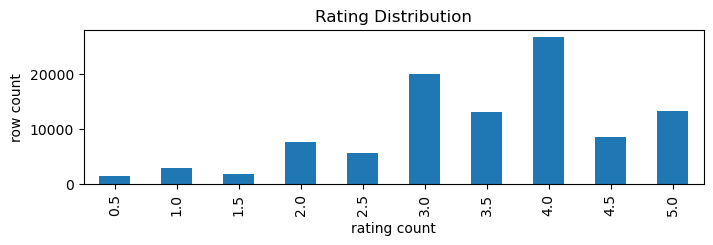

In [26]:
ratings_count.plot(kind="bar", figsize=(8, 2))
plt.title("Rating Distribution")
plt.xlabel("rating count")
plt.ylabel("row count")
plt.show()

## 7. 사용자별 평점 개수

In [30]:
user_rating_count = ratings.groupby('userId').size().reset_index(name="user_rating_count")
print(user_rating_count)

     userId  user_rating_count
0         1                232
1         2                 29
2         3                 39
3         4                216
4         5                 44
..      ...                ...
605     606               1115
606     607                187
607     608                831
608     609                 37
609     610               1302

[610 rows x 2 columns]


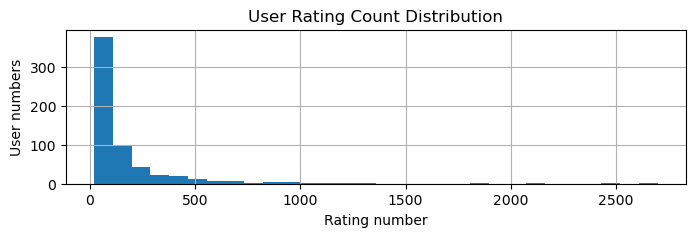

In [37]:
user_rating_count["user_rating_count"].hist(bins=30, figsize=(8,2))
plt.title("User Rating Count Distribution")
plt.xlabel("Rating number")
plt.ylabel("User numbers")
plt.show()

## 8. 영화별 평점 개수 Feature 생성

In [49]:
movie_rating_count = ratings.groupby('movieId').size().reset_index(name="movie_rating_count")
print(movie_rating_count)

      movieId  movie_rating_count
0           1                 215
1           2                 110
2           3                  52
3           4                   7
4           5                  49
...       ...                 ...
9719   193581                   1
9720   193583                   1
9721   193585                   1
9722   193587                   1
9723   193609                   1

[9724 rows x 2 columns]


In [51]:
# 영화별 평점 개수(movie_rating_count) + 영화(movies) 병합
movie_rating_count = movies.merge(movie_rating_count, on="movieId")
print(movie_rating_count)

      movieId                               title  \
0           1                    Toy Story (1995)   
1           2                      Jumanji (1995)   
2           3             Grumpier Old Men (1995)   
3           4            Waiting to Exhale (1995)   
4           5  Father of the Bride Part II (1995)   
...       ...                                 ...   
7215   144976                Bone Tomahawk (2015)   
7216   146656                        Creed (2015)   
7217   146684       Cosmic Scrat-tastrophe (2015)   
7218   148238      A Very Murray Christmas (2015)   
7219   148626                The Big Short (2015)   

                                           genres  movie_rating_count  
0     Adventure|Animation|Children|Comedy|Fantasy                 215  
1                      Adventure|Children|Fantasy                 110  
2                                  Comedy|Romance                  52  
3                            Comedy|Drama|Romance                   7  
4  

In [54]:
# 평점 개수를 기준으로 인기 영화 추천
popular_movies = movie_rating_count.sort_values("movie_rating_count", ascending=False) # sort_values : 값 기준 정렬
popular_movies.head(10)

,movieId,title,genres,movie_rating_count
300,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329
263,318,"Shawshank Redemption, The (1994)",Crime|Drama,317
245,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307
490,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,279
1846,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278
216,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251
401,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,238
93,110,Braveheart (1995),Action|Drama|War,237
487,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,224
443,527,Schindler's List (1993),Drama|War,220


## 9. 영화별 평균 평점 Feature 생성

In [56]:
movie_rating_mean = ratings.groupby("movieId")["rating"].mean().reset_index(name="movie_rating_mean")
movie_rating_mean

,movieId,movie_rating_mean
0,1,3.920930
1,2,3.431818
2,3,3.259615
3,4,2.357143
4,5,3.071429
...,...,...
9719,193581,4.000000
9720,193583,3.500000
9721,193585,3.500000
9722,193587,3.500000


In [59]:
# movie_stats = 평점 개수 + 평균 평점 + 영화 정보
movie_stats = movie_rating_count.merge(movie_rating_mean, on="movieId") # inner join 되기에 how 생략 가능
movie_stats.head()

,movieId,title,genres,movie_rating_count,movie_rating_mean
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,215,3.920930
1,2,Jumanji (1995),Adventure|Children|Fantasy,110,3.431818
2,3,Grumpier Old Men (1995),Comedy|Romance,52,3.259615
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,7,2.357143
4,5,Father of the Bride Part II (1995),Comedy,49,3.071429


In [62]:
# 평점이 높은 영화 정렬
high_rating_movies = movie_stats.sort_values("movie_rating_mean", ascending=False)
high_rating_movies.head(10)
# 결과에 평점 개수가 1인 애들이 위에 몇 나옴. 이러면 제대로 추천 불가.

,movieId,title,genres,movie_rating_count,movie_rating_mean
1178,1631,"Assignment, The (1997)",Action|Thriller,1,5.0
6415,84273,Zeitgeist: Moving Forward (2011),Documentary,1,5.0
3475,5241,Seems Like Old Times (1980),Comedy|Romance,1,5.0
6476,86721,Idiots and Angels (2008),Animation|Drama|Fantasy,1,5.0
5453,47736,"Chump at Oxford, A (1940)",Comedy,1,5.0
2584,3678,"Man with the Golden Arm, The (1955)",Drama,1,5.0
6098,70451,Max Manus (2008),Action|Drama|War,1,5.0
2222,3096,My Man Godfrey (1957),Comedy,1,5.0
4152,6818,Come and See (Idi i smotri) (1985),Drama|War,2,5.0
2213,3086,Babes in Toyland (1934),Children|Comedy|Fantasy|Musical,1,5.0


In [65]:
# 평점 개수가 많고[1순위] 평점이 높은 영화[2순위] 정렬
high_rating_movies2 = movie_stats.sort_values(["movie_rating_count", "movie_rating_mean"], ascending=False)
high_rating_movies2.head(10)
# 얘도 순서가 조금 애매함. 이래서 평점 개수와 평균을 이용한 공식으로 산출하는 거.

,movieId,title,genres,movie_rating_count,movie_rating_mean
300,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134
263,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
245,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068
490,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,279,4.161290
1846,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446
216,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251,4.231076
401,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,238,3.750000
93,110,Braveheart (1995),Action|Drama|War,237,4.031646
487,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,224,3.970982
443,527,Schindler's List (1993),Drama|War,220,4.225000


In [74]:
# 기준 설정(1)
# 평가수(movie_rating_count)가 30개 이상인 영화를 기준
qualified_movie = movie_stats[movie_stats["movie_rating_count"] >= 30]  # boolean indexing
print(qualified_movie)

      movieId                                              title  \
0           1                                   Toy Story (1995)   
1           2                                     Jumanji (1995)   
2           3                            Grumpier Old Men (1995)   
4           5                 Father of the Bride Part II (1995)   
5           6                                        Heat (1995)   
...       ...                                                ...   
7111   122882                          Mad Max: Fury Road (2015)   
7112   122886  Star Wars: Episode VII - The Force Awakens (2015)   
7166   134130                                Martian, The (2015)   
7172   134853                                  Inside Out (2015)   
7192   139385                                The Revenant (2015)   

                                           genres  movie_rating_count  \
0     Adventure|Animation|Children|Comedy|Fantasy                 215   
1                      Adventure|Chil

In [75]:
# 기준 설정(2)
# 분위수 0.75 => 25%, 상위 25%에 해당하는 영화만 출력
# min_rating_count = movie_stats["movie_rating_count"].quantile(0.9)
# qualified_movie = movie_stats[movie_stats["movie_rating_count"] >= min_rating_count]
# print(qualified_movie)
# 아래 함수를 위해 이거 주석 처리함.

## 10. 인기 영화 추천 함수

In [76]:
def recommend_popular_movie(top_n):
    result = (
        qualified_movie.sort_values("movie_rating_mean", ascending=False).head(top_n)
    )

    return result[
        [
            "movieId",
            "title",
            "movie_rating_count",
            "movie_rating_mean"
        ]
    ];

In [77]:
# 인기있는 영화 Top 10
recommend_popular_movie(10)

,movieId,title,movie_rating_count,movie_rating_mean
263,318,"Shawshank Redemption, The (1994)",317,4.429022
868,1204,Lawrence of Arabia (1962),45,4.300000
631,858,"Godfather, The (1972)",192,4.289062
2115,2959,Fight Club (1999),218,4.272936
937,1276,Cool Hand Luke (1967),57,4.271930
579,750,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041
657,904,Rear Window (1954),84,4.261905
884,1221,"Godfather: Part II, The (1974)",129,4.259690
5477,48516,"Departed, The (2006)",107,4.252336
876,1213,Goodfellas (1990),126,4.250000


## 11. 장르 데이터 이해

In [82]:
print(movies.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


## 12. 장르 One-Hot Encoding

In [80]:
# str.get_dummies()
genre_feature = movies["genres"].str.get_dummies(sep="|")
print(genre_feature)

       (no genres listed)  Action  Adventure  Animation  Children  Comedy  \
0                       0       0          1          1         1       1   
1                       0       0          1          0         1       0   
2                       0       0          0          0         0       1   
3                       0       0          0          0         0       1   
4                       0       0          0          0         0       1   
...                   ...     ...        ...        ...       ...     ...   
10324                   0       0          0          1         1       1   
10325                   0       0          0          0         0       1   
10326                   0       0          0          0         0       1   
10327                   0       0          0          0         0       0   
10328                   1       0          0          0         0       0   

       Crime  Documentary  Drama  Fantasy  Film-Noir  Horror  IMAX  Musical

In [81]:
# movies 에 genre_feature 컬럼 추가 - concat
movie_features = pd.concat(
    [
        movies[["movieId", "title", "genres"]],
        genre_feature
    ],
    axis=1
)
print(movie_features.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  (no genres listed)  Action  \
0  Adventure|Animation|Children|Comedy|Fantasy                   0       0   
1                   Adventure|Children|Fantasy                   0       0   
2                               Comedy|Romance                   0       0   
3                         Comedy|Drama|Romance                   0       0   
4                                       Comedy                   0       0   

   Adventure  Animation  Children  Comedy  Crime  ...  Film-Noir  Horror  \
0          1          1         1       1      0  ...          0       0   
1          1          0         1       0      0  ...          0       0   
2 

## 13. 코사인 유사도 불러오기

💥 유사도 행렬(Similarity Matrix) :: 취향이 비슷한 친구 찾기 표본   
    - 사용자 vs 사용자, 영화 vs 영화 가 얼마나 비슷한지 숫자로 표현한 행렬, 유사도를 -1 ~ 1 까지로 표시   
    - 1에 가까울수록 취향이 비슷, 0에 가까울수록 취향이 다름, -1은 반대 취향   

In [83]:
from sklearn.metrics.pairwise import cosine_similarity

In [84]:
genre_columns = genre_feature.columns
print(genre_columns)

Index(['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
       'War', 'Western'],
      dtype='object')


In [85]:
# 영화간 유사도 계산하기
similarity_matrix = cosine_similarity(
    movie_features[genre_columns]
)
print(similarity_matrix)

[[1.         0.77459667 0.31622777 ... 0.4472136  0.         0.        ]
 [0.77459667 1.         0.         ... 0.         0.         0.        ]
 [0.31622777 0.         1.         ... 0.70710678 0.         0.        ]
 ...
 [0.4472136  0.         0.70710678 ... 1.         0.         0.        ]
 [0.         0.         0.         ... 0.         1.         0.        ]
 [0.         0.         0.         ... 0.         0.         1.        ]]


In [89]:
similary_df = pd.DataFrame(
    similarity_matrix,
    index=movie_features["title"],
    columns=movie_features["title"]
)
print(similary_df.head())

title                               Toy Story (1995)  Jumanji (1995)  \
title                                                                  
Toy Story (1995)                            1.000000        0.774597   
Jumanji (1995)                              0.774597        1.000000   
Grumpier Old Men (1995)                     0.316228        0.000000   
Waiting to Exhale (1995)                    0.258199        0.000000   
Father of the Bride Part II (1995)          0.447214        0.000000   

title                               Grumpier Old Men (1995)  \
title                                                         
Toy Story (1995)                                   0.316228   
Jumanji (1995)                                     0.000000   
Grumpier Old Men (1995)                            1.000000   
Waiting to Exhale (1995)                           0.816497   
Father of the Bride Part II (1995)                 0.707107   

title                               Waiting to Exhale

## 14. 특정 영화 검색

In [ ]:
# 1. 정확한 영화 제목 검색
movies[
    movies["title"].str.contains(  # contains() : 문자 찾아주는 거
        못봄
    ) 
]

In [92]:
# 2. 데이터프레임에서 검색한 영화의 인덱스 찾기
movie_index = movies[
    movies["title"] == "Toy Story (1995)"
].index[0]
print(movie_index)

0


In [93]:
# 3. 검색한 영화와 비슷한 모든 유사도를 가진 영화를 가져옴
similarity_scores = list(
    enumerate(similarity_matrix[movie_index])
)
print(similarity_scores)

[(0, np.float64(0.9999999999999999)), (1, np.float64(0.7745966692414835)), (2, np.float64(0.3162277660168379)), (3, np.float64(0.25819888974716115)), (4, np.float64(0.4472135954999579)), (5, np.float64(0.0)), (6, np.float64(0.3162277660168379)), (7, np.float64(0.6324555320336758)), (8, np.float64(0.0)), (9, np.float64(0.25819888974716115)), (10, np.float64(0.25819888974716115)), (11, np.float64(0.3162277660168379)), (12, np.float64(0.7745966692414835)), (13, np.float64(0.0)), (14, np.float64(0.25819888974716115)), (15, np.float64(0.0)), (16, np.float64(0.0)), (17, np.float64(0.4472135954999579)), (18, np.float64(0.4472135954999579)), (19, np.float64(0.19999999999999998)), (20, np.float64(0.25819888974716115)), (21, np.float64(0.0)), (22, np.float64(0.0)), (23, np.float64(0.0)), (24, np.float64(0.0)), (25, np.float64(0.0)), (26, np.float64(0.3162277660168379)), (27, np.float64(0.0)), (28, np.float64(0.39999999999999997)), (29, np.float64(0.0)), (30, np.float64(0.0)), (31, np.float64(0.0

In [ ]:
# 4. 상위 영화 기준으로 정렬
similarity_scores = sorted(
    similarity_scores,
    key=lambda x: x[1],
    reverse=True
)

In [96]:
# 5. 상위 10개 추출 - 💥 첫 번째는 자기 자신이므로 제외
scores = similarity_scores[1:11]
print(scores)

[(1815, np.float64(0.9999999999999999)), (2496, np.float64(0.9999999999999999)), (2967, np.float64(0.9999999999999999)), (3166, np.float64(0.9999999999999999)), (3811, np.float64(0.9999999999999999)), (6617, np.float64(0.9999999999999999)), (6997, np.float64(0.9999999999999999)), (7382, np.float64(0.9999999999999999)), (7987, np.float64(0.9999999999999999)), (9215, np.float64(0.9999999999999999))]


In [97]:
# 6. 추천 영화 인덱스 추출
recommend_indexes = [
    index for index, score in scores
]
movies.iloc[recommend_indexes]

,movieId,title,genres
1815,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2496,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2967,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3166,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3811,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
6617,33463,DuckTales: The Movie - Treasure of the Lost La...,Adventure|Animation|Children|Comedy|Fantasy
6997,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy
7382,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy
7987,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy
9215,91355,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy


## 14. 컨텐츠 기반 추천 함수

In [99]:
def recommend_similar_movies(title, top_n):
    matched_movies = movies[
        movies["title"].str.lower() == title.lower()  # 대소문자 상관없게 데이터 타입을 바꿔줌
    ]

    if matched_movies.empty:
        return pd.DataFrame({"message": ["영화를 찾을 수 없습니다."]})

    movie_index = matched_movies.index[0]

    # 3. 검색한 영화와 비슷한 모든 유사도를 가진 영화를 가져옴
    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )

    # 4. 상위 영화 기준으로 정렬
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # 5. 상위 10개 출력 - 자신은 제외
    similarity_scores = similarity_scores[1:top_n+1]

    # 6. 추천 영화 인덱스 추출
    recommend_indexes = [
        index for index, score in similarity_scores
    ]

    # 7. index 로 영화 찾기
    recommendations = movies.iloc[recommend_indexes][
        ["movieId", "title", "genres"]
    ].copy()

    recommendations["similarity_score"] = [
        score for index, score in similarity_scores
    ]

    return recommendations

In [102]:
recommend_similar_movies("Toy Story (1995)", 10)  # 컨텐츠 베이스 한 거. 여기에다가 평점 추가하면 완벽해짐.

,movieId,title,genres,similarity_score
1815,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.0
2496,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.0
2967,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3166,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3811,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.0
6617,33463,DuckTales: The Movie - Treasure of the Lost La...,Adventure|Animation|Children|Comedy|Fantasy,1.0
6997,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,1.0
7382,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.0
7987,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,1.0
9215,91355,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,1.0


## 15. 컨텐츠 기반 함수 추천 결과 + 협업 필터링 추가(아이템 기반)

In [106]:
movie_result_data = movies.merge(
    movie_stats[
        [
            "movieId",
            "movie_rating_count",
            "movie_rating_mean"
        ]
    ],
    on="movieId",
    how="left"
)
print(movie_result_data.head())
print(movie_result_data.shape)

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  movie_rating_count  \
0  Adventure|Animation|Children|Comedy|Fantasy               215.0   
1                   Adventure|Children|Fantasy               110.0   
2                               Comedy|Romance                52.0   
3                         Comedy|Drama|Romance                 7.0   
4                                       Comedy                49.0   

   movie_rating_mean  
0           3.920930  
1           3.431818  
2           3.259615  
3           2.357143  
4           3.071429  
(10329, 5)


In [111]:
# 💥 컨텐츠 기반 추천 함수에 movie_result_data 를 통해 필터링 작업 수행
# 컨텐츠 기반 함수 수정
def recommend_similar_movies(title, top_n):
    matched_movies = movies[
        movies["title"].str.lower() == title.lower()  # 대소문자 상관없게 데이터 타입을 바꿔줌
    ]

    if matched_movies.empty:
        return pd.DataFrame({"message": ["영화를 찾을 수 없습니다."]})

    movie_index = matched_movies.index[0]

    # 3. 검색한 영화와 비슷한 모든 유사도를 가진 영화를 가져옴
    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )

    # 4. 상위 영화 기준으로 정렬
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # 5. 상위 10개 출력 - 자신은 제외
    similarity_scores = similarity_scores[1:] ## 여기선 자신만 제외하고 for 문 돌려서 하나씩 조건 맞는지 체크.

    # 💥 추가1. 아이템(rating) 기준 협업 필터링 시작
    results = []

    for index, score in similarity_scores:
        movie = movie_result_data.iloc[index]
        if movie["movie_rating_count"] >= 10:
            results.append(
                {
                    "movieId" : movie["movieId"],
                    "title" : movie["title"],
                    "genres" : movie["genres"],
                    "similarity_score": round(score, 2),
                    "rating_count": int(movie["movie_rating_count"]),
                    "rating_mean": round(movie["movie_rating_mean"],2),
                }
            )
        if len(results) == top_n:
            break;

    # 💥 아이템(rating) 기준 협업 필터링 종료
    
    # 6. 추천 영화 인덱스 추출
    #recommend_indexes = [
    #    index for index, score in similarity_scores
    #]

    # 7. index 로 영화 찾기
    #recommendations = movies.iloc[recommend_indexes][
    #    ["movieId", "title", "genres"]
    #].copy()

    #recommendations["similarity_score"] = [
    #    score for index, score in similarity_scores
    #]

    return pd.DataFrame(results)

In [112]:
recommend_similar_movies(
    "Toy Story (1995)",
    10
)

,movieId,title,genres,similarity_score,rating_count,rating_mean
0,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.00,45,3.24
1,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.00,97,3.86
2,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.00,37,3.72
3,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.00,132,3.87
4,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.00,21,3.02
5,673,Space Jam (1996),Adventure|Animation|Children|Comedy|Fantasy|Sc...,0.91,53,2.71
6,4306,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...,0.91,170,3.87
7,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.91,55,4.11
8,108932,The Lego Movie (2014),Action|Adventure|Animation|Children|Comedy|Fan...,0.91,31,3.87
9,1848,"Borrowers, The (1997)",Adventure|Children|Comedy|Fantasy,0.89,12,3.04
